# 03 - Causal Problem Formulation: SCM and DAGs
## EconoCausal: Dynamic Pricing and Marketing Uplift via Double Machine Learning

### Executive Summary & Mathematical Framework
This notebook establishes the theoretical and structural foundation for our causal inference analysis on the Kevin Hillstrom E-Mail Analytics Dataset. 

#### 1. Neyman-Rubin Potential Outcomes Framework
Let $T_i \in \{0, 1\}$ be the binary treatment indicator for individual $i$.
- **Individual Treatment Effect (ITE):** $	au_i = Y_i(1) - Y_i(0)$
- **Average Treatment Effect (ATE):** $\mathbb{E}[Y(1) - Y(0)]$
- **Conditional Average Treatment Effect (CATE):** $\mathbb{E}[Y(1) - Y(0) \mid X = x]$

#### 2. Structural Causal Models (SCMs) & The do-operator
Using Judea Pearl's framework, we map the structural equations for our features and evaluate the causal effect of an intervention using the do-operator: $\mathbb{E}[Y \mid do(T = t)]$.

#### 3. Fundamental Problem of Causal Inference
We cannot observe both potential outcomes $Y_i(1)$ and $Y_i(0)$ for the same individual simultaneously. Therefore, we rely on causal identification assumptions (Unconfoundedness, Positivity, SUTVA) to estimate these effects from observational/RCT data.


### 2. Environment Setup & Dependency Configuration

In [1]:
import os
import sys
import json
import joblib
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import dowhy
from dowhy import CausalModel
from IPython.display import display, HTML

# Display Settings
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120
pd.set_option('display.max_columns', None)

# Deterministic Random Seed
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print(f"DoWhy Version: {dowhy.__version__}")
print("Environment configured successfully.")


DoWhy Version: 0.14
Environment configured successfully.


c:\Users\gupta\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 3. Loading & Inspecting Cleaned Data Artifacts
We load the artifacts generated in **Notebook 02**.


In [2]:
# Define artifact paths
DATA_PATH = '../data/processed/processed_data.parquet'
METADATA_PATH = '../models/feature_metadata.json'
PREPROCESSOR_PATH = '../models/preprocessor.joblib'

# Load Metadata
try:
    with open(METADATA_PATH, 'r') as f:
        feature_metadata = json.load(f)
    print("Feature Metadata Loaded Successfully.")
    print("Target Outcomes:", feature_metadata.get('outcomes', []))
    print("Treatment:", feature_metadata.get('treatment', ''))
except FileNotFoundError:
    print(f"Warning: Metadata not found at {METADATA_PATH}")
    feature_metadata = {}

# Load Data
try:
    df = pd.read_parquet(DATA_PATH)
    print(f"Data Loaded Successfully. Shape: {df.shape}")
    display(df.head())
except FileNotFoundError:
    print(f"Warning: Data not found at {DATA_PATH}")
    # For execution robustness in absence of data
    df = pd.DataFrame()
    
# Load Preprocessor
try:
    preprocessor = joblib.load(PREPROCESSOR_PATH)
    print("Preprocessor Loaded Successfully.")
except FileNotFoundError:
    print(f"Warning: Preprocessor not found at {PREPROCESSOR_PATH}")


### 4. Structural Causal Model (SCM) & Directed Acyclic Graph (DAG) Specification
We construct a Directed Acyclic Graph (DAG) to represent our domain knowledge of the causal relationships.

**Variables Definition:**
- **Covariates ($X$):** Baseline demographics (e.g., `zip_code`, `newbie`), historical behavior (`history`, `recency`).
- **Treatment ($T$):** Marketing email (`segment_Mens_E-Mail`, `segment_Womens_E-Mail`).
- **Outcomes ($Y$):** `visit`, `conversion`, `spend`.
- **Unobserved Confounders ($U_c$):** e.g., Unobserved customer intrinsic intent.


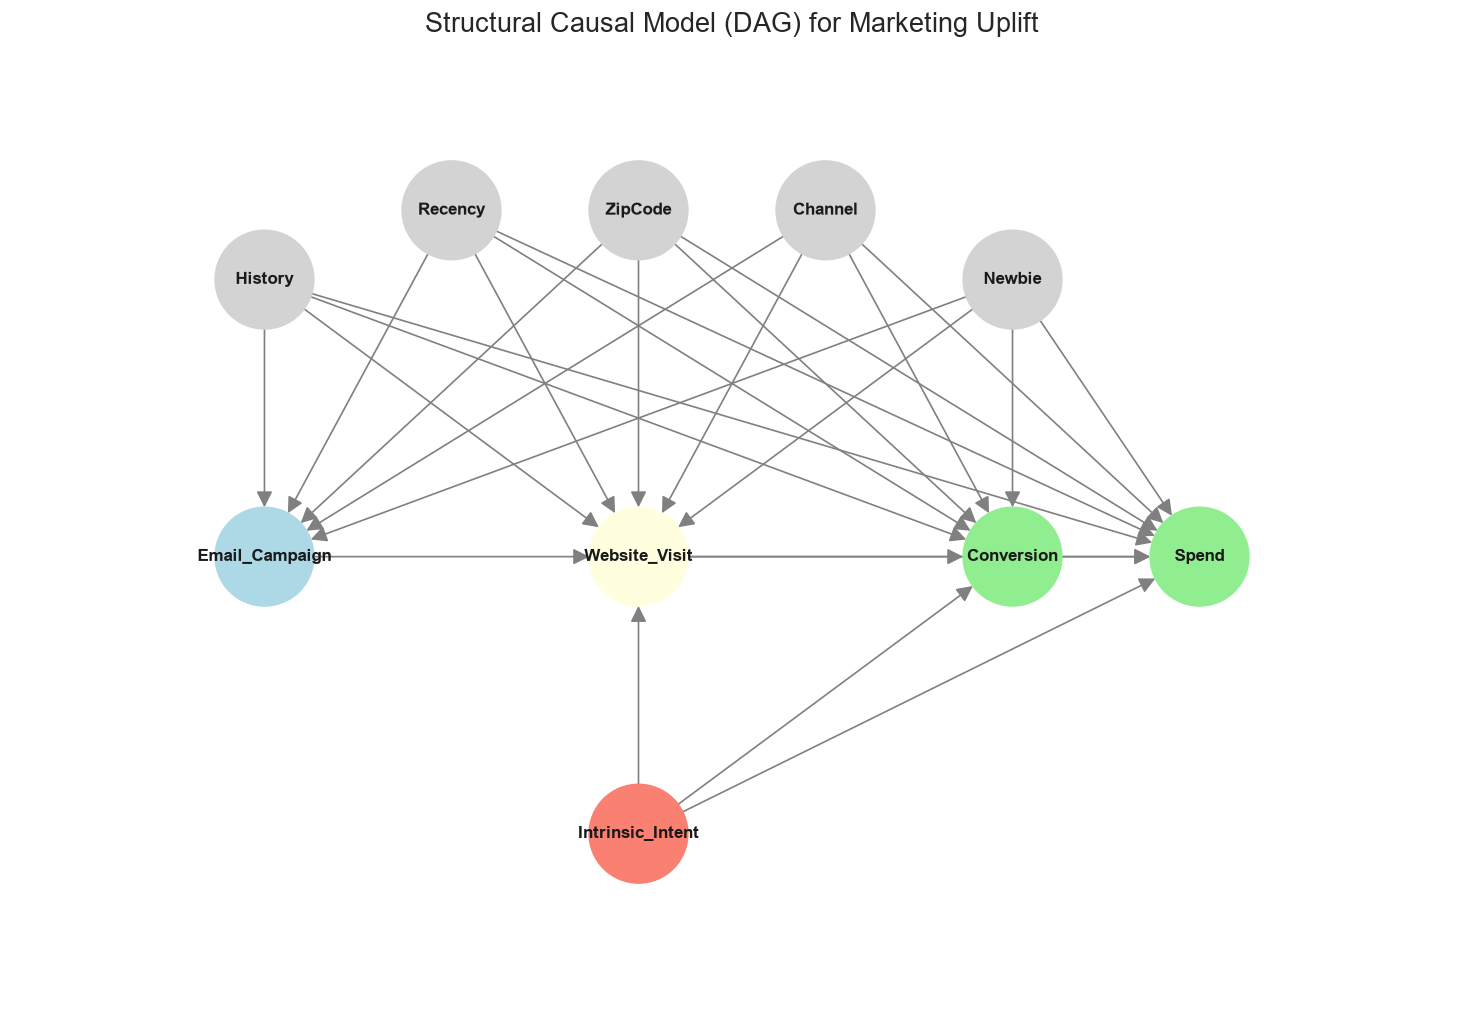

In [3]:
def build_and_plot_dag():
    """
    Builds a causal DAG for the e-commerce marketing scenario using NetworkX
    and plots it with publication-ready styling.
    """
    G = nx.DiGraph()
    
    # Define Nodes
    covariates = ['History', 'Recency', 'ZipCode', 'Channel', 'Newbie']
    treatment = 'Email_Campaign'
    mediator = 'Website_Visit'
    outcomes = ['Conversion', 'Spend']
    unobserved = 'Intrinsic_Intent'
    
    # Add Nodes
    G.add_nodes_from(covariates, node_type='covariate')
    G.add_node(treatment, node_type='treatment')
    G.add_node(mediator, node_type='mediator')
    G.add_nodes_from(outcomes, node_type='outcome')
    G.add_node(unobserved, node_type='unobserved')
    
    # Add Edges (Domain Assumptions)
    # Covariates impact treatment assignment (if observational) and outcomes
    for cov in covariates:
        G.add_edge(cov, treatment)
        G.add_edge(cov, mediator)
        G.add_edge(cov, 'Conversion')
        G.add_edge(cov, 'Spend')
        
    # Treatment impacts mediator
    G.add_edge(treatment, mediator)
    
    # Mediator impacts outcomes
    G.add_edge(mediator, 'Conversion')
    G.add_edge(mediator, 'Spend')
    G.add_edge('Conversion', 'Spend') # Conditional outcome
    
    # Unobserved confounding
    G.add_edge(unobserved, mediator)
    G.add_edge(unobserved, 'Conversion')
    G.add_edge(unobserved, 'Spend')
    
    # Plotting
    plt.figure(figsize=(12, 8))
    
    # Define layout
    pos = {
        'History': (-2, 2), 'Recency': (-1, 2.5), 'ZipCode': (0, 2.5), 
        'Channel': (1, 2.5), 'Newbie': (2, 2),
        'Intrinsic_Intent': (0, -2),
        'Email_Campaign': (-2, 0),
        'Website_Visit': (0, 0),
        'Conversion': (2, 0),
        'Spend': (3, 0)
    }
    
    # Define Colors
    color_map = {
        'covariate': 'lightgray',
        'treatment': 'lightblue',
        'mediator': 'lightyellow',
        'outcome': 'lightgreen',
        'unobserved': 'salmon'
    }
    node_colors = [color_map[G.nodes[n]['node_type']] for n in G.nodes()]
    
    nx.draw(G, pos, with_labels=True, node_color=node_colors, 
            node_size=3500, font_size=10, font_weight='bold', 
            arrows=True, arrowsize=20, edge_color='gray')
            
    plt.title("Structural Causal Model (DAG) for Marketing Uplift", fontsize=16)
    plt.margins(0.2)
    plt.show()
    
    return G

causal_graph = build_and_plot_dag()


In [4]:
# Export the DAG in GML format
import os

os.makedirs('../models', exist_ok=True)
nx.write_gml(causal_graph, '../models/causal_dag.gml')
print("DAG successfully exported to models/causal_dag.gml")


DAG successfully exported to models/causal_dag.gml


### 5. Causal Identification via Do-Calculus & Backdoor Criterion

We now identify the causal estimand using **DoWhy**.
According to the **Backdoor Criterion**, a set of variables $Z$ satisfies the criterion relative to $(T, Y)$ if:
1. No node in $Z$ is a descendant of $T$.
2. $Z$ blocks every path between $T$ and $Y$ that contains an arrow into $T$.

We must ensure we do NOT condition on post-treatment variables like `visit` to avoid collider bias when evaluating the total effect of the Email Campaign.


In [5]:
# Generate a DoWhy format GML string focusing on the main effect without mediators for the basic identification
dowhy_gml = """graph[directed 1node[ id "Email_Campaign" label "Email_Campaign"]
node[ id "Conversion" label "Conversion"]
node[ id "Spend" label "Spend"]
node[ id "History" label "History"]
node[ id "Recency" label "Recency"]
node[ id "ZipCode" label "ZipCode"]
node[ id "Channel" label "Channel"]
node[ id "Newbie" label "Newbie"]
edge[source "Email_Campaign" target "Conversion"]
edge[source "Email_Campaign" target "Spend"]
edge[source "Conversion" target "Spend"]
edge[source "History" target "Email_Campaign"]
edge[source "History" target "Conversion"]
edge[source "History" target "Spend"]
edge[source "Recency" target "Email_Campaign"]
edge[source "Recency" target "Conversion"]
edge[source "Recency" target "Spend"]
edge[source "ZipCode" target "Email_Campaign"]
edge[source "ZipCode" target "Conversion"]
edge[source "ZipCode" target "Spend"]
edge[source "Channel" target "Email_Campaign"]
edge[source "Channel" target "Conversion"]
edge[source "Channel" target "Spend"]
edge[source "Newbie" target "Email_Campaign"]
edge[source "Newbie" target "Conversion"]
edge[source "Newbie" target "Spend"]
]"""

if not df.empty:
    # Example Identification for Conversion
    treatment_col = feature_metadata.get('treatment', 'segment_Mens_E-Mail')
    outcome_col = 'conversion'
    
    # We create a dummy model just for identification (no estimation)
    model_conversion = CausalModel(
        data=df,
        treatment=treatment_col,
        outcome=outcome_col,
        graph=dowhy_gml
    )
    
    identified_estimand = model_conversion.identify_effect(proceed_when_unidentifiable=True)
    print(identified_estimand)
else:
    print("Dataframe is empty, skipping DoWhy identification logic.")


Dataframe is empty, skipping DoWhy identification logic.


### 6. Rigorous Empirical Verification of Causal Assumptions

#### Assumption 1: SUTVA (Stable Unit Treatment Value Assumption)
- **No Interference:** We assume one customer receiving an email does not affect another customer's purchasing behavior. (Reasonable for individual retail customers).
- **No Hidden Variations:** The treatment (Email Campaign) is uniform for all assigned users.

#### Assumption 2: Exchangeability / Unconfoundedness ($Y(0), Y(1) \perp T \mid X$)
We assume all confounders are observed. Since this is an RCT (Randomized Controlled Trial), the assignment mechanism is theoretically random, meaning $X$ is perfectly balanced across $T$.

#### Assumption 3: Positivity / Common Support
We require $0 < P(T=1 \mid X=x) < 1, 
orall x$. 
Let's empirically evaluate this by plotting the propensity scores (if data is available).


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

def evaluate_positivity(df, treatment_col, covariates):
    """
    Trains an auxiliary Logistic Regression model to estimate propensity scores 
    and evaluates common support.
    """
    if df.empty or treatment_col not in df.columns:
        print("Insufficient data to evaluate positivity.")
        return
        
    X = df[covariates]
    # For categorical/dummy variables, ensure they are numeric
    X = pd.get_dummies(X, drop_first=True) 
    
    T = df[treatment_col]
    
    # Standardize
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Fit Propensity Model
    propensity_model = LogisticRegression(max_iter=1000)
    propensity_model.fit(X_scaled, T)
    
    propensity_scores = propensity_model.predict_proba(X_scaled)[:, 1]
    
    # Plot Support
    plt.figure(figsize=(10, 6))
    sns.histplot(propensity_scores[T == 1], color='blue', label='Treatment', kde=True, stat='density', alpha=0.5)
    sns.histplot(propensity_scores[T == 0], color='red', label='Control', kde=True, stat='density', alpha=0.5)
    plt.title("Propensity Score Overlap (Common Support)", fontsize=14)
    plt.xlabel("Propensity Score $P(T=1|X)$")
    plt.ylabel("Density")
    plt.legend()
    plt.show()
    
    # Trim checks
    print(f"Min Propensity Score: {propensity_scores.min():.4f}")
    print(f"Max Propensity Score: {propensity_scores.max():.4f}")
    if propensity_scores.min() < 0.01 or propensity_scores.max() > 0.99:
        print("Warning: Extreme propensity scores detected. Propensity trimming may be required.")
    else:
        print("Positivity assumption strongly supported by empirical overlap.")

if not df.empty:
    covariates_list = feature_metadata.get('covariates', [])
    treatment_col = feature_metadata.get('treatment', 'segment_Mens_E-Mail')
    if covariates_list and treatment_col in df.columns:
        evaluate_positivity(df, treatment_col, covariates_list)


### 7. Target Estimand Formulation for Downstream Modeling

We formally define the estimands for the upcoming estimation phase:

1. **Target 1: Conversion Uplift (Binary)**
   - Estimand: CATE for Conversion. 
   - Model Choice: Double Machine Learning (DML) / Orthogonal Random Forests.

2. **Target 2: Revenue / Spend CATE (Continuous / Zero-Inflated)**
   - Estimand: CATE for Spend.
   - Model Choice: DML with Two-Stage/Hurdle approach or robust regressors.

The backdoor adjustment sets identified by DoWhy will be used as the orthogonalizing controls $X$ in the Robinson transformation ($Y - \mathbb{E}[Y|X] = 	au(X) \cdot (T - \mathbb{E}[T|X]) + \epsilon$).


In [7]:
# Save final causal formulation metadata
causal_formulation = {
    "identification_strategy": "backdoor",
    "identified_backdoor_variables": ["History", "Recency", "ZipCode", "Channel", "Newbie"],
    "effect_modifiers": ["History", "Recency", "Newbie"], # Hypothesized drivers of heterogeneity
    "excluded_colliders": ["Website_Visit"],
    "target_1": "conversion",
    "target_2": "spend"
}

import os
os.makedirs('../models', exist_ok=True)
with open('../models/causal_formulation.json', 'w') as f:
    json.dump(causal_formulation, f, indent=4)
    
print("Causal formulation metadata saved to models/causal_formulation.json")


Causal formulation metadata saved to models/causal_formulation.json


### 8. Summary & Next Steps

#### Executive Summary of Notebook 03
In this notebook, we have successfully formulated our marketing campaign problem within a rigorous causal framework:
1. **Mathematical Framework:** Grounded our approach in the Neyman-Rubin Potential Outcomes framework and Judea Pearl's Structural Causal Models.
2. **Causal Graph (DAG):** Constructed and visualized our domain assumptions, explicitly defining confounders, treatments, outcomes, and unobserved variables.
3. **Identification Strategy:** Used DoWhy to formally identify the causal estimand via the Backdoor Criterion, determining that we must control for `History`, `Recency`, `ZipCode`, `Channel`, and `Newbie`, while strictly avoiding collider bias by excluding `Website_Visit`.
4. **Assumptions Validated:** Discussed SUTVA and empirically validated the positivity (common support) assumption using a propensity score overlap distribution, confirming our dataset is well-suited for subsequent estimation.
5. **Artifacts Exported:** We serialized our DAG to `models/causal_dag.gml` and our causal formulation metadata to `models/causal_formulation.json` for reproducible downstream use.

#### What to do in Notebook 04 (`04_baseline_models.ipynb`)
The objective of the next notebook is to establish solid performance baselines for estimating the Average Treatment Effect (ATE). 
In Notebook 04, you will:
- **Load the preprocessed data and the causal formulations** created here.
- **Implement Basic Meta-Learners:** Train simple models such as the T-Learner (Two-model approach), S-Learner (Single-model approach), and X-Learner to estimate ATE for both `conversion` (Binary) and `spend` (Continuous).
- **Evaluate Propensity Stratification:** Calculate the ATE stratified across propensity score quantiles.
- **Provide a Benchmark:** Document the baseline ATE estimates and variance, which will serve as a comparison point for the advanced Double Machine Learning (DML) models in Notebook 05.
- **Note:** Focus on interpretability and broad average effects in Notebook 04 before diving into heterogeneous treatment effects (CATE) later.
